In [1]:
cd ..

/home/bhchen/LearnKalmanGain


--- Processing Metric: mean_cov_diff ---
    Saved plot to save/figures/lorenz63_rcov_diff_1e-3.pdf


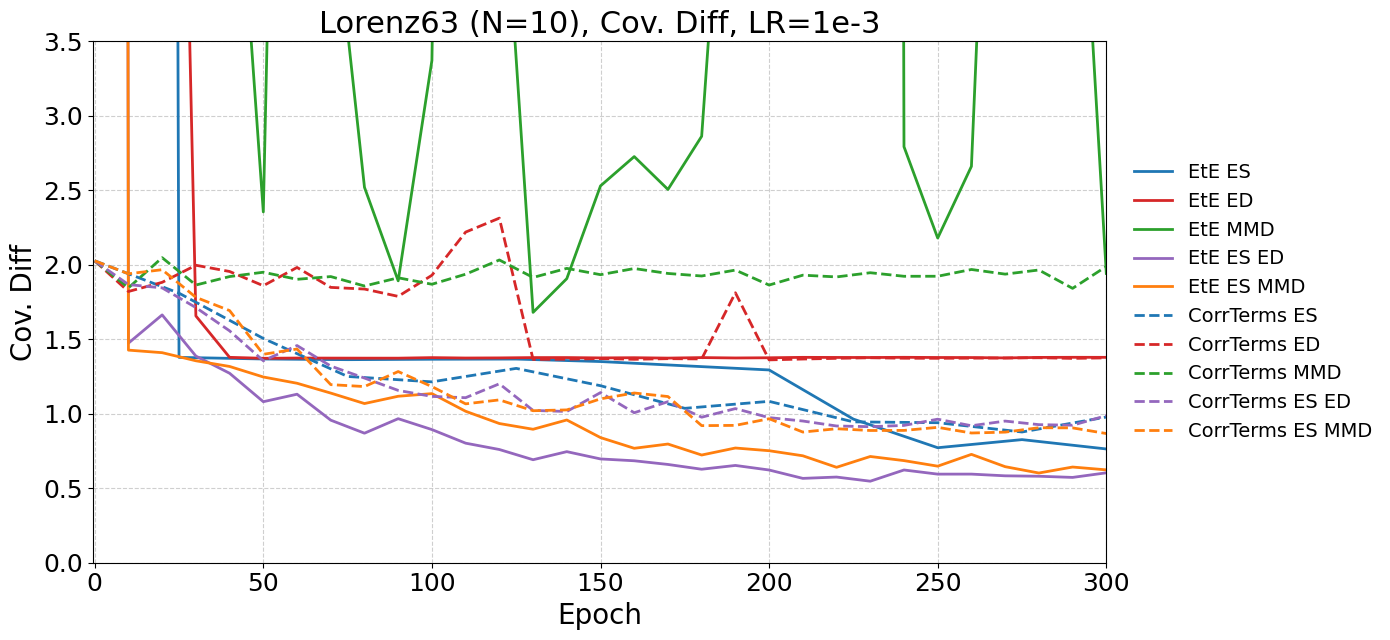

--- Processing Metric: mean_pf_rrmse ---
    Saved plot to save/figures/lorenz63_pf_rrmse_1e-3.pdf


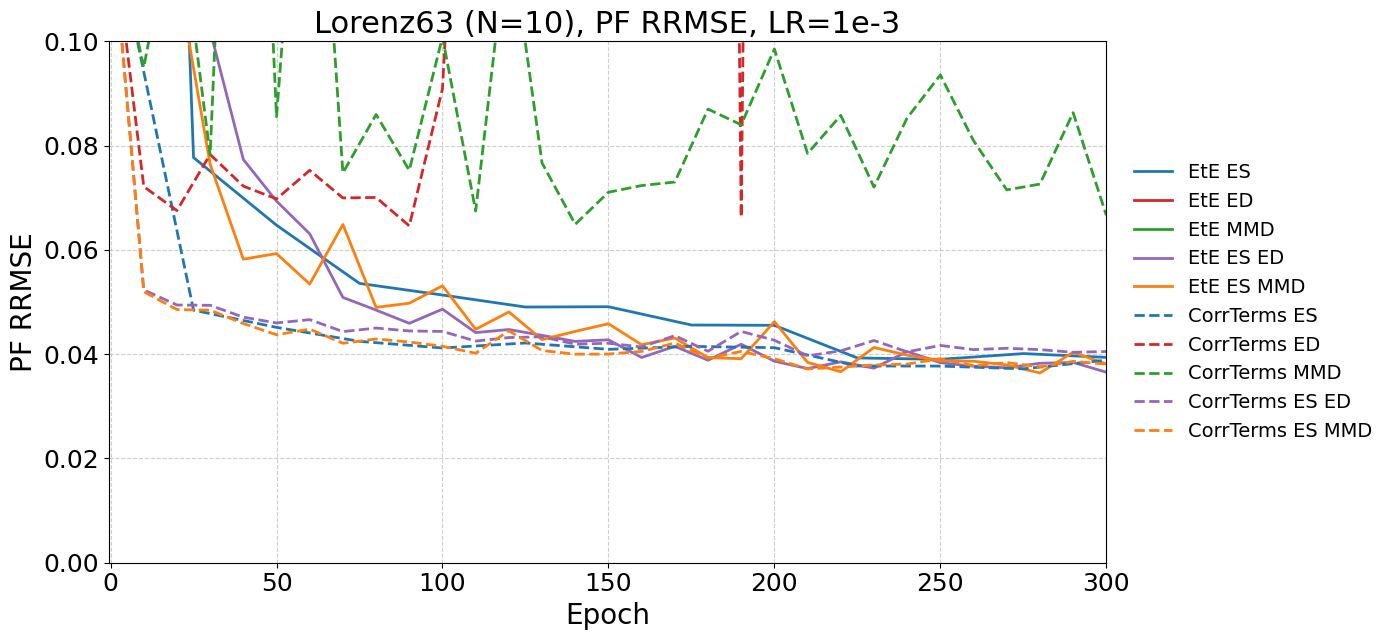

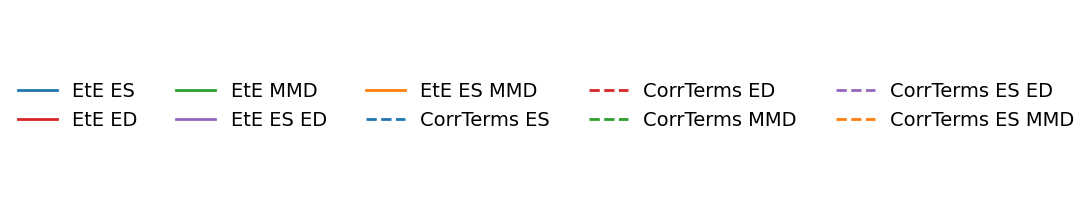

In [2]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================

SHOW_SIDE_LEGEND = True
FIGSIZE_MAIN = (14, 6.5) if SHOW_SIDE_LEGEND else (10, 6.5)
FIGSIZE_LEGEND = (10, 2.5) # Increased height for more items

MAIN_LINE_WIDTH = 2.0
X_LIM = (-0.5, 300) 
GRID_LS = "--"
GRID_ALPHA = 0.6

TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 14 

# =================== Data Configuration ===================

benchmark_data = {} # Empty for now as per your snippet

metrics_config = [
    {
        "key": 'mean_cov_diff',
        "ylabel": "Cov. Diff",
        "fname": "rcov_diff",
        "ylim": (0, 3.5) 
    },
    {
        "key": 'mean_pf_rrmse',
        "ylabel": "PF RRMSE",
        "fname": "pf_rrmse",
        "ylim": (0, 0.1) 
    }
]

lr_folder_map = {
    "1e-3": [
        "2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
        "2026-01-21_14-42lorenz63_1.0_10_60_8192_wpf_ed_joint_EtE-LRes",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_EtE-LRes",
        "2026-01-14_01-06lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ed_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_CorrTerms",
    ],
}

method_names = ['EtE ES','EtE ED', 'EtE MMD', 'EtE ES ED', 'EtE ES MMD', 'CorrTerms ES', 'CorrTerms ED', 'CorrTerms MMD', 'CorrTerms ES ED', 'CorrTerms ES MMD']

lrs_to_plot = ["1e-3"] 
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Helper: Style Logic ===================

def get_method_style(name):
    """
    Determines color and linestyle based on method name semantics.
    Input: method name (str)
    Output: dict with 'color', 'linestyle'
    """
    # 1. Determine Line Style (Family)
    # EtE -> Solid
    # CorrTerms -> Dashed
    if "CorrTerms" in name:
        ls = "--"
    else:
        ls = "-"

    # 2. Determine Color (Variant)
    # Using Tab10 palette for high contrast
    # Check compound keys first (e.g., 'ES ED') to avoid partial match issues
    if "ES ED" in name:
        color = "tab:purple"
    elif "ES MMD" in name:
        color = "tab:orange"
    elif "ES" in name:
        color = "tab:blue"
    elif "ED" in name:
        color = "tab:red"
    elif "MMD" in name:
        color = "tab:green"
    else:
        color = "black"

    return {"color": color, "linestyle": ls}

# =================== Main Loops ===================

for metric in metrics_config:
    print(f"--- Processing Metric: {metric['key']} ---")
    
    for lr in lrs_to_plot:
        folder_names = lr_folder_map.get(lr, [])
        if not folder_names: continue

        fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
        title_str = f"Lorenz63 (N=10), {metric['ylabel']}, LR={lr}"
        ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

        # 1. Plot Training Methods
        for i, folder_name in enumerate(folder_names):
            file_path = os.path.join('save', 'lorenz63_wpf', folder_name, 'training_records.pt')
            
            if not os.path.exists(file_path):
                print(f"    Missing file: {folder_name}")
                continue

            data = torch.load(file_path, weights_only=True)
            curve = np.array(data.get(metric['key'], []))
            epochs = np.array(data.get('test_epochs', []))
            
            name = method_names[i]
            style = get_method_style(name) # Get dynamic style

            if len(curve) > 0:
                ax.plot(epochs, curve, 
                        linewidth=MAIN_LINE_WIDTH, 
                        label=name,
                        color=style['color'],
                        linestyle=style['linestyle'])
            else:
                print(f"    Empty key {metric['key']} in {folder_name}")

        # 2. Benchmark Lines (if any)
        for b_name, b_values in benchmark_data.items():
            y_val = b_values.get(metric['key'])
            if y_val is not None:
                # ... (benchmark plotting code remains same) ...
                pass 

        # 3. Formatting
        ax.set_ylabel(metric['ylabel'], fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
        ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
        ax.set_xlim(*X_LIM)
        if metric['ylim']:
            ax.set_ylim(*metric['ylim'])
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        # 4. Side Legend 
        if SHOW_SIDE_LEGEND:
            ax.legend(
                loc='center left', 
                bbox_to_anchor=(1, 0.5), 
                fontsize=LEGEND_FONTSIZE,
                frameon=False,
                borderaxespad=1  # Add padding between plot and legend
            )

        save_path = os.path.join(out_dir, f"lorenz63_{metric['fname']}_{lr}.pdf")
        fig.tight_layout()
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"    Saved plot to {save_path}")
        plt.show(fig) 

# =================== Standalone Legend (Optional) ===================
# Only needed if you want a separate file for the legend
fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
handles, labels = ax.get_legend_handles_labels()
# Organize handles if needed (e.g. sort by family)
ax_legend.legend(handles, labels, loc='center', ncol=5, frameon=False, fontsize=LEGEND_FONTSIZE)
plt.show(fig_legend)

--- Processing Metric: mean_cov_diff ---
    Saved plot to save/figures/lorenz63_rcov_diff_1e-3.pdf


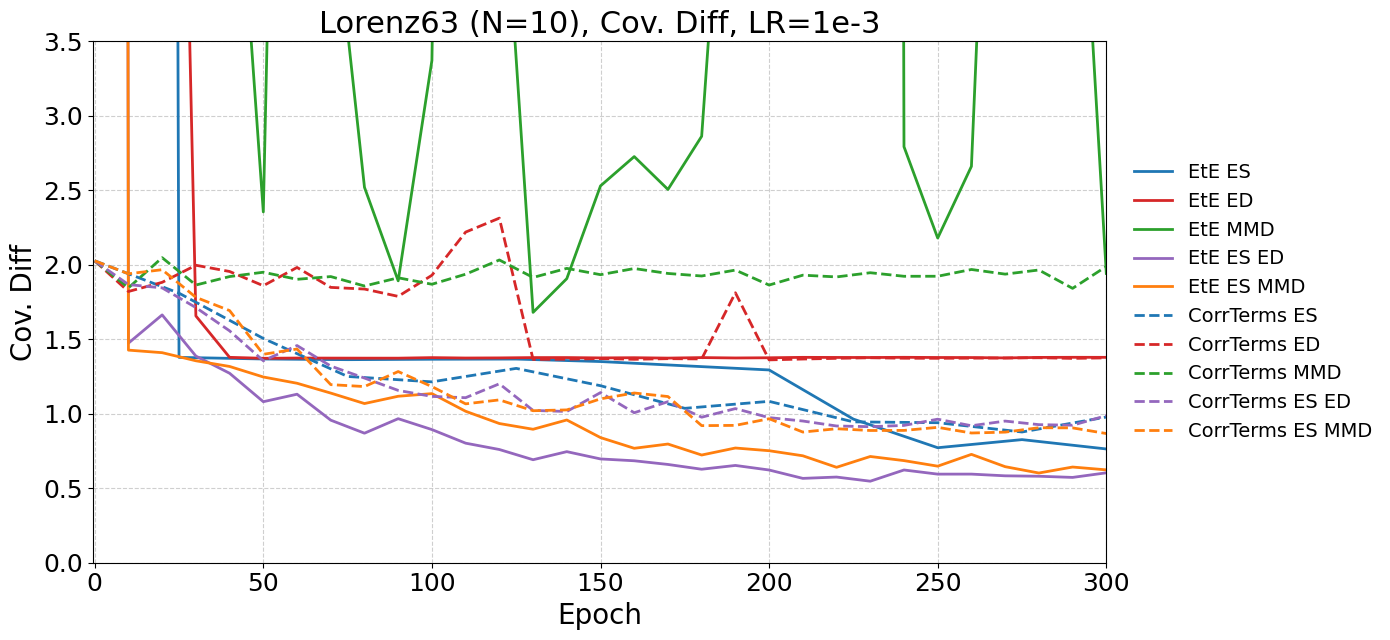

--- Processing Metric: mean_pf_rrmse ---
    Saved plot to save/figures/lorenz63_pf_rrmse_1e-3.pdf


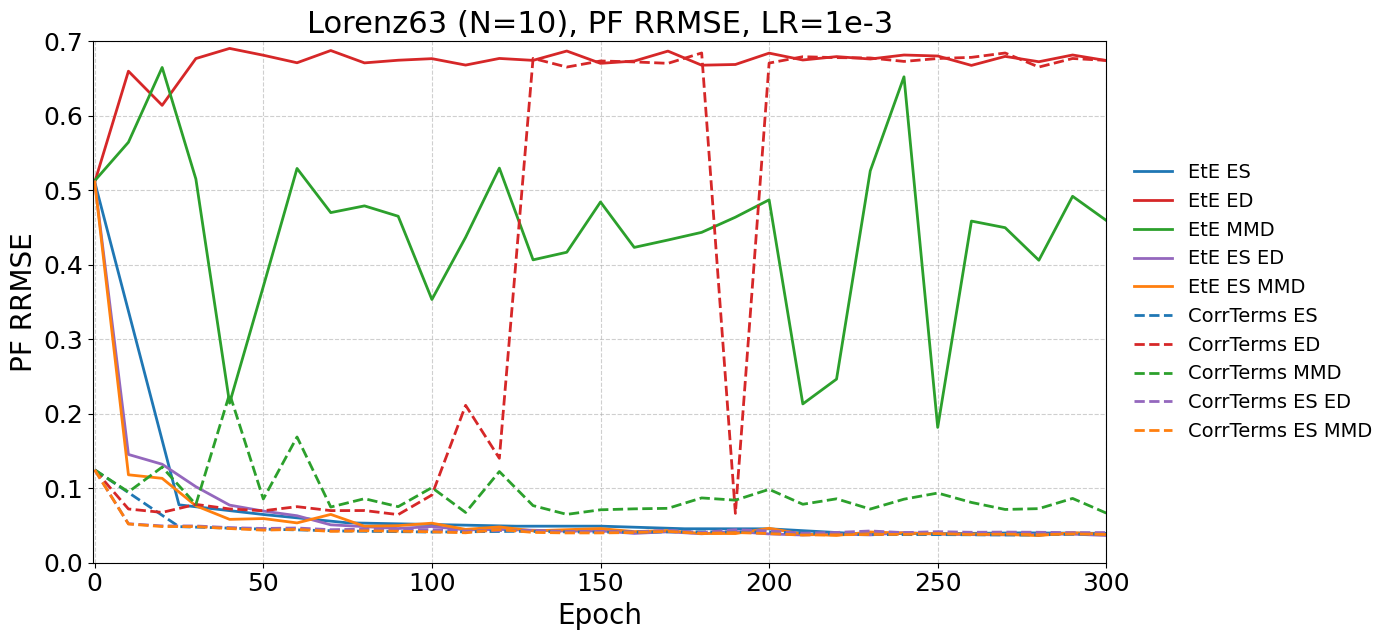

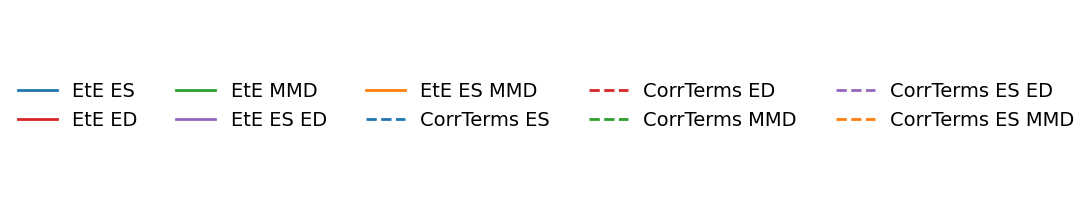

In [3]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================

SHOW_SIDE_LEGEND = True
FIGSIZE_MAIN = (14, 6.5) if SHOW_SIDE_LEGEND else (10, 6.5)
FIGSIZE_LEGEND = (10, 2.5) # Increased height for more items

MAIN_LINE_WIDTH = 2.0
X_LIM = (-0.5, 300) 
GRID_LS = "--"
GRID_ALPHA = 0.6

TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 14 

# =================== Data Configuration ===================

benchmark_data = {} # Empty for now as per your snippet

metrics_config = [
    {
        "key": 'mean_cov_diff',
        "ylabel": "Cov. Diff",
        "fname": "rcov_diff",
        "ylim": (0, 3.5) 
    },
    {
        "key": 'mean_pf_rrmse',
        "ylabel": "PF RRMSE",
        "fname": "pf_rrmse",
        "ylim": (0, 0.7) 
    }
]

lr_folder_map = {
    "1e-3": [
        "2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
        "2026-01-21_14-42lorenz63_1.0_10_60_8192_wpf_ed_joint_EtE-LRes",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_EtE-LRes",
        "2026-01-14_01-06lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ed_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_CorrTerms",
    ],
}

method_names = ['EtE ES','EtE ED', 'EtE MMD', 'EtE ES ED', 'EtE ES MMD', 'CorrTerms ES', 'CorrTerms ED', 'CorrTerms MMD', 'CorrTerms ES ED', 'CorrTerms ES MMD']

lrs_to_plot = ["1e-3"] 
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Helper: Style Logic ===================

def get_method_style(name):
    """
    Determines color and linestyle based on method name semantics.
    Input: method name (str)
    Output: dict with 'color', 'linestyle'
    """
    # 1. Determine Line Style (Family)
    # EtE -> Solid
    # CorrTerms -> Dashed
    if "CorrTerms" in name:
        ls = "--"
    else:
        ls = "-"

    # 2. Determine Color (Variant)
    # Using Tab10 palette for high contrast
    # Check compound keys first (e.g., 'ES ED') to avoid partial match issues
    if "ES ED" in name:
        color = "tab:purple"
    elif "ES MMD" in name:
        color = "tab:orange"
    elif "ES" in name:
        color = "tab:blue"
    elif "ED" in name:
        color = "tab:red"
    elif "MMD" in name:
        color = "tab:green"
    else:
        color = "black"

    return {"color": color, "linestyle": ls}

# =================== Main Loops ===================

for metric in metrics_config:
    print(f"--- Processing Metric: {metric['key']} ---")
    
    for lr in lrs_to_plot:
        folder_names = lr_folder_map.get(lr, [])
        if not folder_names: continue

        fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
        title_str = f"Lorenz63 (N=10), {metric['ylabel']}, LR={lr}"
        ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

        # 1. Plot Training Methods
        for i, folder_name in enumerate(folder_names):
            file_path = os.path.join('save', 'lorenz63_wpf', folder_name, 'training_records.pt')
            
            if not os.path.exists(file_path):
                print(f"    Missing file: {folder_name}")
                continue

            data = torch.load(file_path, weights_only=True)
            curve = np.array(data.get(metric['key'], []))
            epochs = np.array(data.get('test_epochs', []))
            
            name = method_names[i]
            style = get_method_style(name) # Get dynamic style

            if len(curve) > 0:
                ax.plot(epochs, curve, 
                        linewidth=MAIN_LINE_WIDTH, 
                        label=name,
                        color=style['color'],
                        linestyle=style['linestyle'])
            else:
                print(f"    Empty key {metric['key']} in {folder_name}")

        # 2. Benchmark Lines (if any)
        for b_name, b_values in benchmark_data.items():
            y_val = b_values.get(metric['key'])
            if y_val is not None:
                # ... (benchmark plotting code remains same) ...
                pass 

        # 3. Formatting
        ax.set_ylabel(metric['ylabel'], fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
        ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
        ax.set_xlim(*X_LIM)
        if metric['ylim']:
            ax.set_ylim(*metric['ylim'])
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        # 4. Side Legend 
        if SHOW_SIDE_LEGEND:
            ax.legend(
                loc='center left', 
                bbox_to_anchor=(1, 0.5), 
                fontsize=LEGEND_FONTSIZE,
                frameon=False,
                borderaxespad=1  # Add padding between plot and legend
            )

        save_path = os.path.join(out_dir, f"lorenz63_{metric['fname']}_{lr}.pdf")
        fig.tight_layout()
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"    Saved plot to {save_path}")
        plt.show(fig) 

# =================== Standalone Legend (Optional) ===================
# Only needed if you want a separate file for the legend
fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
handles, labels = ax.get_legend_handles_labels()
# Organize handles if needed (e.g. sort by family)
ax_legend.legend(handles, labels, loc='center', ncol=5, frameon=False, fontsize=LEGEND_FONTSIZE)
plt.show(fig_legend)